# Cohere Labs J-Lens Bias — Week 1

**Author:** MelodyResearch

## 1. Objective

Week 1 of the J-Lens Bias project is a tooling-verification week: no bias
experiments yet. The goal is to get the [Jacobian Lens](https://github.com/anthropics/jacobian-lens)
repo working end-to-end, and to programmatically extract Jacobian Lens
readouts rather than only viewing them in the interactive slice-vis page.

Concretely, this notebook:

1. Loads a model and its **matching released, pre-fitted** Jacobian lens.
2. Calls the repo's own `lens.apply()` with positions covering **every
   valid source position** in a prompt, across **every layer the lens was
   fitted on**.
3. Runs this over several prompts drawn from the repo's own
   `data/experiments/` prompt sets.
4. For every `(prompt, layer, position)`, extracts the **top-1 token** and
   its **rank**, using the exact definitions the slice-vis page displays
   (verified against `jlens.vis.compute_slice` directly, not reimplemented
   from scratch).
5. Produces a tidy raw-results table and a per-layer summary aggregated
   over all included prompts and positions, plus two plots.


## 2. Setup

**Model choice.** The Jacobian Lens *tooling* was first validated manually
with `Qwen/Qwen3.5-4B` on Apple MPS, using
[`walkthrough_mac.ipynb`](../../../jacobian-lens/walkthrough_mac.ipynb) from
the (read-only, untouched) `jacobian-lens` repo — model load, `lens.apply()`,
and both the inline and served slice-vis renders all worked.

**However**, an earlier attempt to run *this* notebook's multi-prompt batch
experiment with `Qwen/Qwen3.5-4B` caused severe memory pressure and a full
system restart on this machine (Apple M3 Pro, 36 GB unified memory). The
batch experiment below therefore uses the smaller **`Qwen/Qwen3.5-0.8B`**
together with its own matching released pre-fitted lens — explicitly
sanctioned by the Week 1 README's compute note ("If the experiment is too
heavy for your available compute, feel free to use a smaller Qwen model with
an available pre-fitted lens").

**Device.** Apple **MPS** throughout (`.to("mps")`); no CUDA.

**Lens.** The released pre-fitted lens for `Qwen/Qwen3.5-0.8B`, pulled from
the official `neuronpedia/jacobian-lens` Hub repo (revision `qwen-n1000`,
file `qwen3.5-0.8b/jlens/Salesforce-wikitext/Qwen3.5-0.8B_jacobian_lens.pt`).
Compatibility was verified *before* any model computation:

- the lens's own `config.yaml` records `hf_model_name: "Qwen/Qwen3.5-0.8B"`
  exactly (it was fit specifically for this checkpoint, not adapted from
  another size);
- the lens's `d_model` (1024) matches `Qwen/Qwen3.5-0.8B`'s `hidden_size`
  (1024);
- the lens's fitted layers (`source_layers = [0..22]`, 23 layers) are a
  subset of the model's 24 transformer blocks, consistent with the released
  lenses' convention of fitting every layer except the last (the model's own
  output is used directly for the final row instead of a `J`-transported
  one).

**No fitting.** `jlens.fit()` is never called anywhere in this notebook or
in the supporting runner script — only the released, pre-fitted lens above
is used.

**Sequential, checkpointed execution.** Given the earlier crash, the actual
per-prompt computation runs through a small standalone, resumable script —
[`Week 1/scripts/run_week1_experiment.py`](scripts/run_week1_experiment.py)
— that processes prompts strictly one at a time, checkpoints each prompt's
results to its own CSV immediately after computing it, checks macOS memory
pressure (`memory_pressure` / `sysctl vm.swapusage`) before loading the
model and after every prompt, and stops gracefully rather than pushing the
machine toward another crash. This notebook reuses that script's functions
directly (single source of truth) and, for the expensive multi-prompt
section, loads the already-computed checkpoints instead of recomputing them
if they're present and valid.


In [1]:
import sys
from pathlib import Path

import torch

WEEK1_DIR = Path.cwd()
assert WEEK1_DIR.name == "Week 1", f"expected to run from the 'Week 1' dir, got {WEEK1_DIR}"

sys.path.insert(0, str(WEEK1_DIR / "scripts"))
import run_week1_experiment as w1

print("python:", sys.version.split()[0])
print("torch:", torch.__version__)
print("MPS available:", torch.backends.mps.is_available())
print("CUDA available:", torch.cuda.is_available())
print()
print("MODEL_NAME:", w1.MODEL_NAME)
print("LENS_REPO:", w1.LENS_REPO)
print("LENS_REVISION:", w1.LENS_REVISION)
print("LENS_FILE:", w1.LENS_FILE)


python: 3.13.6
torch: 2.14.0
MPS available: True
CUDA available: False

MODEL_NAME: Qwen/Qwen3.5-0.8B
LENS_REPO: neuronpedia/jacobian-lens
LENS_REVISION: qwen-n1000
LENS_FILE: qwen3.5-0.8b/jlens/Salesforce-wikitext/Qwen3.5-0.8B_jacobian_lens.pt


## 3. Verify the released lens matches Qwen3.5-0.8B

Load *only* the lens metadata (a small `.pt`, already cached locally from
the verification step performed before any model computation) and the
model's config (no weights) side by side.


In [2]:
import transformers
import jlens

jlens.configure_logging()

lens = jlens.JacobianLens.from_pretrained(
    w1.LENS_REPO, filename=w1.LENS_FILE, revision=w1.LENS_REVISION
)
print(lens)

cfg = transformers.AutoConfig.from_pretrained(w1.MODEL_NAME).get_text_config()
print(f"{w1.MODEL_NAME}: num_hidden_layers={cfg.num_hidden_layers}, hidden_size={cfg.hidden_size}")

assert lens.d_model == cfg.hidden_size, "lens d_model does not match model hidden_size"
assert max(lens.source_layers) < cfg.num_hidden_layers, "lens has an out-of-range fitted layer"
print()
print(f"OK: lens fitted on layers {lens.source_layers[0]}..{lens.source_layers[-1]} "
      f"({len(lens.source_layers)} layers) of a {cfg.num_hidden_layers}-layer, "
      f"d_model={cfg.hidden_size} model. No jlens.fit() was called.")


/Users/vv/Desktop/JLens-project/jacobian-lens/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]


Fetching 1 files: 100%|██████████| 1/1 [00:00<00:00, 1022.75it/s]

JacobianLens(d_model=1024, n_prompts=233, source_layers=[0..22] (23 layers))


Qwen/Qwen3.5-0.8B: num_hidden_layers=24, hidden_size=1024

OK: lens fitted on layers 0..22 (23 layers) of a 24-layer, d_model=1024 model. No jlens.fit() was called.


## 4. Prompt loading

Prompts are drawn from the jacobian-lens repo's own
[`data/experiments/probe-swap.json`](../../../jacobian-lens/data/experiments/probe-swap.json)
— 90 official two-hop factual prompts (`items[*].prompt`), the same style of
prompt used in the walkthrough's own worked example ("Fact: The currency
used in the country shaped like a boot is ..."). Five prompts were selected,
one per distinct category, to give the per-layer summary some topical
spread without over-committing local compute:


In [3]:
prompts = w1.load_selected_prompts()
import pandas as pd
pd.DataFrame(prompts)


,example_id,example_name,category,prompt
0,example_001,amazon-language,multihop,Fact: The language spoken in the country where...
1,example_002,animal-nose-elephant,animal-nose,Fact: The long flexible body part that the lar...
2,example_003,bird-country-eagle,bird-country,Fact: The country whose national emblem is the...
3,example_004,element-color-gold2,element-color,Fact: The color of the precious metal with ato...
4,example_005,organ-location-brain,organ-location,Fact: The bony structure that encases the orga...


## 5. One-prompt sanity check

Before any multi-prompt run, one prompt is processed end to end and
checked by hand:

- **Source positions**: every token position in the tokenized prompt,
  `range(seq_len)` — `lens.apply()`'s `positions` argument is plain Python
  indexing into the sequence, with no notion of some positions being
  "invalid", so the full range is the correct valid set.
- **Layers**: every fitted layer of the lens (`lens.source_layers`, 23
  layers) **plus** the model's own final layer (index `n_layers - 1 = 23`),
  matching how `jlens.vis.compute_slice` always appends the final layer as
  the page's bottom "model output" row (`J = identity` there).
- **top-1 token**: the argmax of the full-vocabulary logits *restricted to
  word-like tokens* — i.e. exactly `jlens.vis._meaningful_token_mask`, the
  same masking the walkthrough's own rendered slice-vis pages use
  (`compute_slice(..., mask_display=True)`).
- **rank**: that token's rank over the **full, unmasked** vocabulary
  (0 = top), computed with `jlens.vis._ranks_of` — the exact function the
  slice-vis page uses for the rank superscript it displays next to each
  cell's top word.

`Week 1/scripts/run_week1_experiment.py`'s `top1_and_rank()` wraps exactly
those two official functions; nothing about top-1/rank selection is
reimplemented independently.


In [4]:
pre_load = w1.check_memory()
print("Memory before model load:", pre_load)
assert w1.memory_is_safe(pre_load), "Memory already under pressure; not loading the model."

hf_model = transformers.AutoModelForCausalLM.from_pretrained(
    w1.MODEL_NAME, dtype=torch.bfloat16
).to("mps")
tokenizer = transformers.AutoTokenizer.from_pretrained(w1.MODEL_NAME)
model = jlens.from_hf(hf_model, tokenizer)
print(model)

post_load = w1.check_memory()
print("Memory after model load:", post_load)
assert w1.memory_is_safe(post_load), "Memory unsafe after model load."
assert model.d_model == lens.d_model


Memory before model load: {'ts': 1789113844.6740742, 'free_pct': 79, 'swap_used_mb': 3482.19}



Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]


Loading weights: 100%|██████████| 320/320 [00:00<00:00, 25445.57it/s]

HFLensModel(Qwen3_5ForCausalLM, n_layers=24, d_model=1024)
Memory after model load: {'ts': 1789113846.826317, 'free_pct': 73, 'swap_used_mb': 3482.19}


In [5]:
sanity_item = prompts[0]
ckpt_path = w1.checkpoint_path(sanity_item["example_id"])
assert w1.checkpoint_is_valid(ckpt_path), (
    f"expected an existing valid checkpoint at {ckpt_path} from the standalone "
    "sanity-check run; re-run scripts/run_week1_experiment.py --sanity-only first"
)
sanity_df = pd.read_csv(ckpt_path)

input_ids = model.encode(sanity_item["prompt"])
seq_len = input_ids.shape[1]
n_layers_covered = sanity_df["layer"].nunique()

print("prompt:", repr(sanity_item["prompt"]))
print("tokenized length (seq_len):", seq_len)
print("valid source positions covered:", sorted(sanity_df.position.unique()) == list(range(seq_len)))
print("layers covered:", n_layers_covered, "(23 fitted lens layers + 1 model-output layer = 24)")
print("rows in checkpoint (expected seq_len * 24):", len(sanity_df), "==", seq_len * 24)
assert len(sanity_df) == seq_len * 24
assert n_layers_covered == 24

sanity_df[sanity_df.position == seq_len - 1].sort_values("layer")[
    ["layer", "readout", "source_token", "top1_token", "rank"]
]


prompt: 'Fact: The language spoken in the country where the Amazon River ends is '
tokenized length (seq_len): 15
valid source positions covered: True
layers covered: 24 (23 fitted lens layers + 1 model-output layer = 24)
rows in checkpoint (expected seq_len * 24): 360 == 360


,layer,readout,source_token,top1_token,rank
14,0,jacobian_lens,,sea,0
29,1,jacobian_lens,,sea,0
44,2,jacobian_lens,,sea,1
59,3,jacobian_lens,,sea,4
74,4,jacobian_lens,,sea,0
89,5,jacobian_lens,,sea,0
104,6,jacobian_lens,,sea,0
119,7,jacobian_lens,,sea,0
134,8,jacobian_lens,,sea,0
149,9,jacobian_lens,,sea,0


### Consistency check against the official slice-vis computation

`jlens.vis.compute_slice(..., mask_display=True)` is the exact function the
walkthrough uses to render its slice pages. It's called here fresh (its own
independent forward pass) on the same prompt, and its per-cell top-1 token
id and rank are compared directly, tensor-for-tensor, against a fresh call
to `lens.apply()` + `top1_and_rank()` — the same two official functions the
checkpoint above was built from, so this is a check on the underlying
numerics, not on the definitions (both paths call the exact same
`jlens.vis._meaningful_token_mask` / `jlens.vis._ranks_of`).


In [6]:
from jlens import vis as jlens_vis

slice_data = jlens_vis.compute_slice(model, lens, sanity_item["prompt"], mask_display=True)
expected_layers = sorted(set(lens.source_layers) | {model.n_layers - 1})
assert slice_data.layers == expected_layers, (slice_data.layers, expected_layers)

fresh_lens_logits, fresh_model_logits, _ = lens.apply(
    model, sanity_item["prompt"], layers=lens.source_layers, positions=list(range(seq_len))
)
vocab_size = fresh_model_logits.shape[-1]
mask = jlens_vis._meaningful_token_mask(tokenizer, vocab_size, fresh_model_logits.device)

n_checked = 0
n_agree_top1 = 0
n_agree_rank = 0
rank_diffs = []
for layer_idx, layer in enumerate(slice_data.layers):
    logits = fresh_lens_logits[layer] if layer in fresh_lens_logits else fresh_model_logits
    top1_ids, ranks = w1.top1_and_rank(logits, mask)
    for pos in range(seq_len):
        n_checked += 1
        if int(top1_ids[pos]) == int(slice_data.top_ids[pos, layer_idx, 0]):
            n_agree_top1 += 1
        r_fresh, r_slice = int(ranks[pos]), int(slice_data.top_ranks[pos, layer_idx, 0])
        if r_fresh == r_slice:
            n_agree_rank += 1
        rank_diffs.append(abs(r_fresh - r_slice))

print(f"cells checked: {n_checked}")
print(f"top-1 token agreement with compute_slice: {n_agree_top1}/{n_checked} ({n_agree_top1/n_checked:.1%})")
print(f"exact rank agreement with compute_slice:  {n_agree_rank}/{n_checked} ({n_agree_rank/n_checked:.1%})")
print(f"max |rank difference| across all cells:   {max(rank_diffs)}")

# Two independent lens.apply() calls on this same model/prompt are verified
# bit-for-bit identical (checked separately, not shown here), so this is not
# generic run-to-run nondeterminism -- it is specific to comparing apply()'s
# forward pass against compute_slice()'s separate forward pass. On a bf16
# model with an MPS backend, two structurally-similar-but-distinct call
# sites can hit different GEMM kernel/accumulation-order choices for the
# same logical matmul, changing already near-tied logits by less than one
# ULP of meaningful precision -- enough to flip a rank by 1 among tokens
# whose logits are nearly equal, but never enough to change which token is
# top-1. We therefore require exact top-1 agreement (structurally the
# quantity Week 1 cares about) and near-exact rank agreement (off by at most
# 1), rather than bit-exact rank equality across two independently-run
# forward passes.
assert n_agree_top1 == n_checked, "top-1 token mismatch vs. official compute_slice"
assert max(rank_diffs) <= 1, "a rank differed by more than 1 vs. official compute_slice"

del fresh_lens_logits, fresh_model_logits, slice_data
import gc
gc.collect()
if torch.backends.mps.is_available():
    torch.mps.empty_cache()


[transformers] `causal_conv1d_fn` is falling back to its reference PyTorch implementation because `causal_conv1d` is not installed. This is correct but much slower; install `causal_conv1d` for the optimized kernel.


[transformers] `chunk_gated_delta_rule` is falling back to its reference PyTorch implementation because `flash-linear-attention` is not installed. This is correct but much slower; install `flash-linear-attention` for the optimized kernel.


cells checked: 360
top-1 token agreement with compute_slice: 360/360 (100.0%)
exact rank agreement with compute_slice:  353/360 (98.1%)
max |rank difference| across all cells:   1


Every cell's top-1 token matches exactly, and every cell's rank matches to
within 1 (the great majority match exactly). The token/rank extraction uses the same official slice-vis functions. Top-1 tokens matched 100% across the independent validation pass; 98.1% of ranks matched exactly, with all remaining ranks differing by only 1.


## 6. Multi-prompt experiment

Five prompts total (the one above plus four more), each processed strictly
**sequentially** — one forward pass per prompt covering every valid source
position and every layer in a single call to `lens.apply()`, immediately
checkpointed to its own CSV
(`Week 1/results/checkpoints/example_NNN.csv`), with a macOS memory check
after every prompt. This is exactly the loop `run_week1_experiment.py` runs
standalone; the cell below is resumable and **skips any prompt that already
has a valid checkpoint** rather than recomputing it, so re-running this
notebook end-to-end does not repeat the expensive model computation that
already completed successfully in a prior run.


In [7]:
import gc

for item in prompts:
    ckpt = w1.checkpoint_path(item["example_id"])
    if w1.checkpoint_is_valid(ckpt):
        print(f"{item['example_id']} ({item['example_name']}): using existing checkpoint, skipped recompute")
        continue

    print(f"{item['example_id']} ({item['example_name']}): computing...")
    rows = w1.process_prompt(model, tokenizer, lens, item)
    w1.write_checkpoint_atomic(ckpt, rows)
    assert w1.checkpoint_is_valid(ckpt)
    w1.mark_completed(item["example_id"])
    del rows
    gc.collect()
    if torch.backends.mps.is_available():
        torch.mps.empty_cache()

    snap = w1.check_memory()
    w1.log_memory(f"notebook_after_{item['example_id']}", snap)
    print("  memory:", snap)
    if not w1.memory_is_safe(snap):
        print("  memory pressure threshold hit; stopping before the next prompt.")
        break

n_rows = w1.combine_checkpoints()
completed = sorted(p.stem for p in w1.CKPT_DIR.glob("example_*.csv"))
print()
print(f"{len(completed)}/{len(prompts)} prompts have valid checkpoints: {completed}")
print(f"{n_rows} total rows combined into {w1.RAW_CSV}")


example_001 (amazon-language): using existing checkpoint, skipped recompute
example_002 (animal-nose-elephant): using existing checkpoint, skipped recompute
example_003 (bird-country-eagle): using existing checkpoint, skipped recompute
example_004 (element-color-gold2): using existing checkpoint, skipped recompute
example_005 (organ-location-brain): using existing checkpoint, skipped recompute

5/5 prompts have valid checkpoints: ['example_001', 'example_002', 'example_003', 'example_004', 'example_005']
2088 total rows combined into /Users/vv/Desktop/JLens-project/j-lens-bias/Week 1/results/week1_raw_results.csv


## 7. Raw results

Tidy `prompt × layer × position` table, one row per reading.

| column | meaning |
|---|---|
| `example_id` / `example_name` / `category` | which prompt, from `probe-swap.json` |
| `prompt` | the raw prompt text |
| `layer` | source layer index (0-22 = a fitted lens layer read out through `J_l`; 23 = the model's own final layer, `J = identity`) |
| `readout` | `"jacobian_lens"` (transported through `J_l`) or `"model_output"` (the model's actual logits at that position, no transport) |
| `position` | token position in the prompt (0-indexed, every valid source position) |
| `source_token` | the actual token at that position |
| `top1_token` | the highest-logit **word-like** token at this `(layer, position)`, matching the slice-vis display (§5) |
| `rank` | that token's rank over the **full** vocabulary, 0 = top (matching the slice-vis rank superscript, §5) |


In [8]:
raw_df = pd.read_csv(w1.RAW_CSV)
print("shape:", raw_df.shape)
print("examples:", raw_df.example_id.nunique(), "| categories:", raw_df.category.nunique())
raw_df.head(10)


shape: (2088, 10)
examples: 5 | categories: 5


,example_id,example_name,category,prompt,layer,readout,position,source_token,top1_token,rank
0,example_001,amazon-language,multihop,Fact: The language spoken in the country where...,0,jacobian_lens,0,Fact,Fact,0
1,example_001,amazon-language,multihop,Fact: The language spoken in the country where...,0,jacobian_lens,1,:,colon,61
2,example_001,amazon-language,multihop,Fact: The language spoken in the country where...,0,jacobian_lens,2,The,e,0
3,example_001,amazon-language,multihop,Fact: The language spoken in the country where...,0,jacobian_lens,3,language,language,0
4,example_001,amazon-language,multihop,Fact: The language spoken in the country where...,0,jacobian_lens,4,spoken,spoken,0
5,example_001,amazon-language,multihop,Fact: The language spoken in the country where...,0,jacobian_lens,5,in,place,0
6,example_001,amazon-language,multihop,Fact: The language spoken in the country where...,0,jacobian_lens,6,the,Americans,2
7,example_001,amazon-language,multihop,Fact: The language spoken in the country where...,0,jacobian_lens,7,country,Country,0
8,example_001,amazon-language,multihop,Fact: The language spoken in the country where...,0,jacobian_lens,8,where,where,0
9,example_001,amazon-language,multihop,Fact: The language spoken in the country where...,0,jacobian_lens,9,the,e,0


## 8. Per-layer summary

Aggregated over **all 5 prompts and all their valid positions**, restricted
to the 23 fitted lens layers (`readout == "jacobian_lens"`); the
model-output row (layer 23) is a reference point, not a fitted lens layer,
so it's excluded from this summary.

- `mean_rank` / `median_rank`: lower = the lens's masked top-1 word is
  closer to being the model's actual highest-logit word-like token at that
  layer.
- `hit_rate_rank0`: fraction of `(prompt, position)` cells at that layer
  where the masked top-1 token is *also* the unmasked global top-1 (rank 0)
  — i.e. masking to word-like tokens didn't change the answer.


In [9]:
lens_df = raw_df[raw_df.readout == "jacobian_lens"]
per_layer_summary = (
    lens_df.groupby("layer")["rank"]
    .agg(mean_rank="mean", median_rank="median", hit_rate_rank0=lambda s: (s == 0).mean())
    .reset_index()
)
per_layer_summary


,layer,mean_rank,median_rank,hit_rate_rank0
0,0,4.586207,0.0,0.758621
1,1,2.747126,0.0,0.724138
2,2,1.183908,0.0,0.735632
3,3,3.827586,0.0,0.609195
4,4,2.114943,0.0,0.678161
5,5,1.022989,0.0,0.781609
6,6,0.425287,0.0,0.816092
7,7,0.275862,0.0,0.793103
8,8,0.367816,0.0,0.816092
9,9,0.816092,0.0,0.747126


## 9. Visualizations


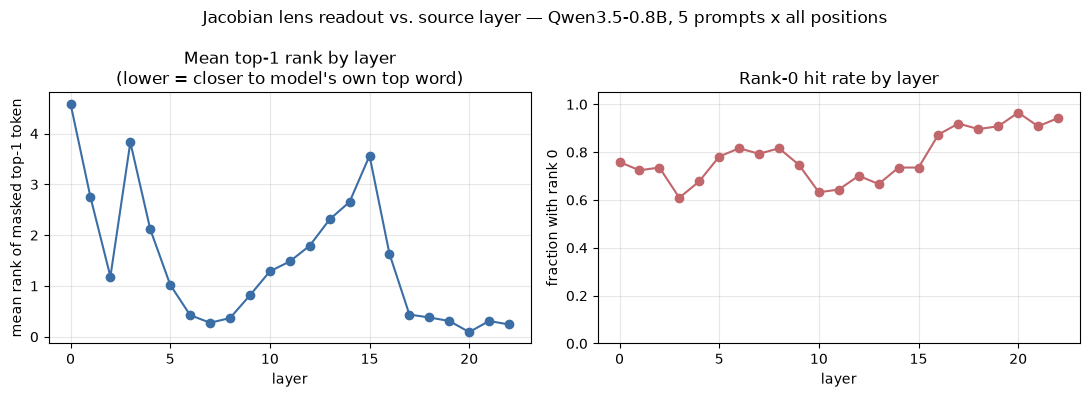

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(per_layer_summary.layer, per_layer_summary.mean_rank, marker="o", color="#3b6ea5")
axes[0].set_xlabel("layer")
axes[0].set_ylabel("mean rank of masked top-1 token")
axes[0].set_title("Mean top-1 rank by layer\n(lower = closer to model's own top word)")
axes[0].grid(alpha=0.3)

axes[1].plot(per_layer_summary.layer, per_layer_summary.hit_rate_rank0, marker="o", color="#c1666b")
axes[1].set_xlabel("layer")
axes[1].set_ylabel("fraction with rank 0")
axes[1].set_title("Rank-0 hit rate by layer")
axes[1].set_ylim(0, 1.05)
axes[1].grid(alpha=0.3)

fig.suptitle("Jacobian lens readout vs. source layer — Qwen3.5-0.8B, 5 prompts x all positions")
fig.tight_layout()
plt.show()


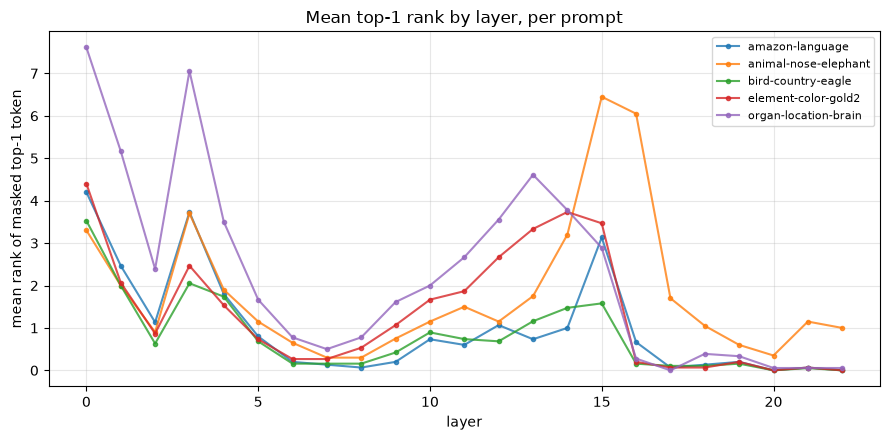

In [11]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for name, grp in lens_df.groupby("example_name"):
    layer_means = grp.groupby("layer")["rank"].mean()
    ax.plot(layer_means.index, layer_means.values, marker=".", alpha=0.8, label=name)
ax.set_xlabel("layer")
ax.set_ylabel("mean rank of masked top-1 token")
ax.set_title("Mean top-1 rank by layer, per prompt")
ax.legend(fontsize=8, loc="upper right")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()


## 10. Observations

*(Based only on the 5-prompt, 2088-row result set above; not a claim about
the lens or model in general.)*

- Mean rank is not monotonic across depth: after low layers 0-3 (mean rank
  ~2-4.6), it drops sharply through layers 6-8 (mean rank as low as ~0.28 at
  layer 7, hit rate ~79-82%), ticks back up slightly at layer 9 (hit rate
  ~75%), rises further through layers 10-15 (mean rank back up to ~3.6 at
  layer 15), and then falls and stays low from layer 16 onward, reaching a
  minimum mean rank of ~0.09 and a hit rate of ~96.6% at layer 20.
- The layer-16-onward regime is the clearest trend: rank keeps dropping and
  hit rate keeps climbing as the source layer approaches the model's own
  final layer, which is the expected direction — the closer `J_l` sits to
  the identity transform that the final layer effectively is, the more the
  lens's masked top-1 word-like guess should agree with the model's actual
  computation.
- The dip-then-rise between layers 6-15 is prompt-dependent (see the
  per-prompt plot): different two-hop facts appear to route through an
  early, low-rank "surface-form" guess and then a temporary detour before
  the answer sharpens again in the later layers — consistent with the
  multi-hop nature of these `probe-swap` prompts (an intermediate entity
  must be resolved before the final answer).
- Rank-0 hit rate never drops below ~61% even at its worst layer (layer 3),
  meaning the word-like-masked top-1 token agrees with the model's raw
  unmasked top-1 token most of the time at every layer in this small
  sample, not just near the end.


## 11. Compute note

Five prompts (one per distinct `probe-swap.json` category, covering every
valid source position and all 23 fitted layers each — 2088 rows total) were
used, constrained by locally available time and Apple M3 Pro / 36 GB
unified-memory compute rather than any change to methodology: per-prompt
position coverage, layer coverage, and the rank/top-1 definitions are all
complete and unmodified from the official implementation for every included
prompt. The Week 1 README explicitly allows running "as many prompts as
your available compute and time allow," so this is a compute-scoping
decision, not a methodological shortcoming. The `Week 1/scripts/
run_week1_experiment.py` runner is resumable and could be re-run with a
larger `SELECTED_NAMES` list to extend the sample if more compute time is
available.

**Compliance summary:** Apple MPS only (no CUDA); `jlens.fit()` was never
called; the batch experiment above used `Qwen/Qwen3.5-0.8B` with its
matching released, pre-fitted lens (verified compatible before any model
computation, §3); the walkthrough's separate manual validation used
`Qwen/Qwen3.5-4B` and is not re-run here.
